In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import torch.nn.functional as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Model and Tokenizer

I am going to use GPT-2 from Huggingface.

In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model name
model_name = "gpt2"

# Load tokenizer 
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(device)
model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [3]:
# Tokenizer padding (we use EOS as PAD)

tokenizer.pad_token = tokenizer.eos_token

In [4]:
# Quick test

prompt = "The capital of France is"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
print("logits shape: ", logits.shape)

logits shape:  torch.Size([1, 5, 50257])


## 2. Tokenization deep dive

I explore how text is convertend into tokens. I analyze/
* How text is split into subword tokens by BPE
* Tokens ID and their meaning
* The relationship between tokens and decoded text

In [5]:
# Tokenize text an returns in the form of a pytorch tensor

text = "The capital of France is Paris"
inputs = tokenizer(text, return_tensors="pt")

In [6]:
# Extract input_ids tensor

input_ids = inputs["input_ids"]
input_ids = input_ids.to(device)

print("Input IDs tensors:")
print(input_ids)

Input IDs tensors:
tensor([[ 464, 3139,  286, 4881,  318, 6342]])


In [7]:
# Convert:
# 1. tensor to a list
# 2. each token id into its string representation

token_ids = input_ids[0].tolist()

print("Token IDs:")
print(token_ids)

tokens = [tokenizer.decode([tid]) for tid in token_ids]

print("\nTokens:")
print(tokens)

Token IDs:
[464, 3139, 286, 4881, 318, 6342]

Tokens:
['The', ' capital', ' of', ' France', ' is', ' Paris']


In [8]:
# Tokenization more into details

print("\nDetailed token mapping:\n")

for tid in token_ids:
    token_str = tokenizer.decode([tid])
    print(f"ID: {tid} -> Token: '{token_str}'")


Detailed token mapping:

ID: 464 -> Token: 'The'
ID: 3139 -> Token: ' capital'
ID: 286 -> Token: ' of'
ID: 4881 -> Token: ' France'
ID: 318 -> Token: ' is'
ID: 6342 -> Token: ' Paris'


In [9]:
# Test on other examples

texts = ["Hello world", "my name is Chiara", "unbelievable", "that is amazing!"]

for text in texts:
    print("Text: ", text)
    input_ids = tokenizer(text)["input_ids"]
    tokens = [tokenizer.decode([tid]) for tid in input_ids]
    print("Tokens: ", tokens)

Text:  Hello world
Tokens:  ['Hello', ' world']
Text:  my name is Chiara
Tokens:  ['my', ' name', ' is', ' Chi', 'ara']
Text:  unbelievable
Tokens:  ['un', 'bel', 'iev', 'able']
Text:  that is amazing!
Tokens:  ['that', ' is', ' amazing', '!']


Tokens are not necessarily words:
* They can include spaces
* They can be sub-words
* They can be punctuation
* They are case sensitive

## 3. Next Token Prediction

I study how GPT predict the next token. Key concepts:
* The model outputs logits for each token in the vocabulary
* Softmax is applied to convert logits into probabilities
* Focus on the last token to predict the next

In [10]:
# Tokenization of the input

text = "The capital of France is"

inputs = tokenizer(text, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

In [11]:
# Extract logits

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
print("logits shape: ", logits.shape)

logits shape:  torch.Size([1, 5, 50257])


In [12]:
# Logits only from the last token of the input sentence

last_token_logits = logits[:, -1, :]
print("Last token logits shape: ", last_token_logits.shape)

Last token logits shape:  torch.Size([1, 50257])


In [13]:
# Convert into probabilities

probs = F.softmax(last_token_logits, dim=-1)
probs = probs[0]

In [14]:
# What are the top-k tokens (most probable)?

top_k = 10

top_probs, top_indices = torch.topk(probs, top_k)

print(f"\nTop-{top_k} next token predictions:\n")

for i in range(top_k):
    token_id = top_indices[i].item()
    token_prob = top_probs[i].item()

    token_str = tokenizer.decode([token_id])

    print(f"{i+1}. token '{token_str}' | prob: {token_prob:.4f}")


Top-10 next token predictions:

1. token ' the' | prob: 0.0846
2. token ' now' | prob: 0.0479
3. token ' a' | prob: 0.0462
4. token ' France' | prob: 0.0324
5. token ' Paris' | prob: 0.0322
6. token ' in' | prob: 0.0266
7. token ' also' | prob: 0.0264
8. token ' not' | prob: 0.0238
9. token ' home' | prob: 0.0233
10. token ' still' | prob: 0.0155


## 4. Greedy Decoding

It selects the most likely token at each step:
1. It starts from an initial prompt
2. Predict next token
3. Appen the token to the sequence
4. Repeat

In [15]:
# Function to perform greedy decoding

def greedy_generate(prompt, max_new_tokens=20):

    # Tokenize the input
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    input_ids = input_ids.to(device)

    # Generate new tokens
    for step in range(max_new_tokens):
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            
        logits = outputs.logits
        last_token_logits = logits[:, -1, :]
        probs = F.softmax(last_token_logits, dim=-1)

        # Greedy choice: most likely token
        next_token_id = torch.argmax(probs, dim=-1).unsqueeze(0)
        input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    generated_text = tokenizer.decode(input_ids[0])

    return generated_text

In [16]:
# Test

prompt = "The capital of France is"

output = greedy_generate(prompt, max_new_tokens=15)
output

'The capital of France is the capital of the French Republic, and the capital of the French Republic is'

As expected, Greedy doen't provide the best output overall and it creates repetitions.

## 5. Temperature scaling

I introduce the temperature, to control the randomness of the model's predictions, instead of using the most probable token (greedy).
* Low temperature (<1) makes the model more deterministic
* High temperature (>1) makes the model more random

In [17]:
# Function to apply temperature scaling

def sample_with_temperature(logits, temperature=1.0):

    # Divide logits by temperature and convert into probs
    scaled_logits = logits / temperature
    probs = F.softmax(scaled_logits, dim=-1)

    # Sample from the prob distribution
    next_token_id = torch.multinomial(probs, num_samples=1)

    return next_token_id

In [18]:
# Function to generate tokens using temperature

def generate_with_temperature(prompt, max_new_tokens=20, temperature=1.0):

    # Tokenize the input
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    input_ids = input_ids.to(device)

    # Generate new tokens
    for step in range(max_new_tokens):
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            
        logits = outputs.logits
        last_token_logits = logits[:, -1, :]

        next_token_id = sample_with_temperature(last_token_logits, temperature)
        input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    generated_text = tokenizer.decode(input_ids[0])

    return generated_text

In [19]:
# Test

prompt = "The meaning of life is"

for T in [0.1, 0.7, 1.0, 1.5, 2.0]:
    print("\nTemperature: ", T)
    print(generate_with_temperature(prompt, max_new_tokens=20, temperature=T))


Temperature:  0.1
The meaning of life is not to be confused with the meaning of life.

The meaning of life is not to be

Temperature:  0.7
The meaning of life is to die. It is supposed to be a sacred ritual, but in reality it is almost as though

Temperature:  1.0
The meaning of life is simple. According to Natural Law, we have an unfettered acceptability of immortality." According to

Temperature:  1.5
The meaning of life is critically earned, though arena seasons don't claim upon those commemorated consumers Recently used drug streaming sources team

Temperature:  2.0
The meaning of life is rarely rule promulgated sanction effective INS staplesattering at Clip of fourteen prevents arranged resists encoded staples rotating How


Some insights:
* When T=0.1 the model is very repetitive
* When 0.7<T<1.0 the model gives more natural outputs
* When T>1.5 it becomes nonsense

## 6. Top-k sampling

I combine this with the temperature scaling. In particular:
* I keep the top K most probable tokens
* All the others are set to 0 probability
* Renormalize and sample

In [20]:
# Function for the top K sampling

def top_k_sampling(logits, k=50, temperature=1.0):

    # Divide logits by temperature 
    scaled_logits = logits / temperature

    # Get top K logits and mask unwanted ones
    top_k_logits, top_k_indices = torch.topk(scaled_logits, k)
    filtered_logits = torch.full_like(scaled_logits, float('-inf'))
    filtered_logits.scatter_(1, top_k_indices, top_k_logits)

    # Convert logits into probs and sample
    probs = F.softmax(scaled_logits, dim=-1)
    next_token_id = torch.multinomial(probs, num_samples=1)

    return next_token_id

In [21]:
def generate_top_k(prompt, max_new_tokens=20, k=50, temperature=1.0):

    # Tokenize the input
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    input_ids = input_ids.to(device)

    # Generate new tokens
    for step in range(max_new_tokens):
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            
        logits = outputs.logits
        last_token_logits = logits[:, -1, :]

        next_token_id = top_k_sampling(last_token_logits, k=k, temperature=temperature)
        input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    generated_text = tokenizer.decode(input_ids[0])

    return generated_text

In [22]:
prompt = "The future of AI is"

for k in [1, 5, 10, 20, 50, 70]:
    print(f"\nTop K: {k}")
    print(generate_top_k(prompt, max_new_tokens=20, k=k, temperature=0.7))


Top K: 1
The future of AI is unknown, but we know that machine learning will be a key part of it, and that it will

Top K: 5
The future of AI is not yet clear but is something that is likely to be demonstrated by the development of AI systems that take

Top K: 10
The future of AI is uncertain. But if the technology is viable, it will need to be decentralized. There are good reasons

Top K: 20
The future of AI is cloud computing and the dark age of managerialism.

How AI Will Change Medical Science



Top K: 50
The future of AI is fully defined by the implementation of a Turing-complete programming language dubbed the Big Bang Theory, which predicts

Top K: 70
The future of AI is still in the early stages. It could be used to detect patterns in the world around us, and


## 7. Top-p nucleus sampling

To avoid situations where probability distributions are too peaked or viceversa, I use another sampling strategy:
1. Sort tokens by probability
2. Keep the smallest set whose cumulative prob is more than $p$
3. Sample from this subset

In [23]:
# Function for the top K sampling

def top_p_sampling(logits, p=0.9, temperature=1.0):

    # Divide logits by temperature 
    scaled_logits = logits / temperature

    # Convert logits into probs and sample
    probs = F.softmax(scaled_logits, dim=-1)

    # Sort by prob
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    # Mask for tokens to remove
    sorted_mask = cumulative_probs > p
    sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
    sorted_mask[..., 0] = False

    # Probs for masked tokens to 0
    sorted_probs[sorted_mask] = 0.0

    # Renormalize and sample
    sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    next_token_index = torch.multinomial(sorted_probs, num_samples=1)
    next_token_id = sorted_indices.gather(-1, next_token_index)

    return next_token_id

In [24]:
def generate_top_p(prompt, max_new_tokens=20, p=0.9, temperature=1.0):

    # Tokenize the input
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    input_ids = input_ids.to(device)

    # Generate new tokens
    for step in range(max_new_tokens):
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            
        logits = outputs.logits
        last_token_logits = logits[:, -1, :]

        next_token_id = top_p_sampling(last_token_logits, p=p, temperature=temperature)
        input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    generated_text = tokenizer.decode(input_ids[0])

    return generated_text

In [25]:
# Test

prompt = "The future of AI is"

for p in [0.7, 0.8, 0.9, 0.95]:
    print(f"\nTop P: {p}")
    print(generate_top_p(prompt, max_new_tokens=20, p=p, temperature=0.7))


Top P: 0.7
The future of AI is a long way off.

The first step is to build a machine that can understand the world

Top P: 0.8
The future of AI is still a long way off. But it's not clear how much of it is due to advances in

Top P: 0.9
The future of AI is uncertain, but there is some hope.

"If we can develop a neural network that is

Top P: 0.95
The future of AI is unclear, but some are already looking at what's next.

AI is already on the rise


## 8. Unified generation function

I combine all the generation strategies:
* Greedy
* Temperature sampling
* Top-K sampling
* Top-P sampling

to create a unique pipeline

In [26]:
def generate(prompt, max_new_tokens=20, strategy="greedy", temperature=0.8, top_k=50, top_p=0.9):

    # Tokenize the input
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    input_ids = input_ids.to(device)

    # Generate new tokens
    for step in range(max_new_tokens):
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            
        logits = outputs.logits
        last_token_logits = logits[:, -1, :]

        if strategy != "greedy":
            last_token_logits = last_token_logits / temperature

        # 1. Greedy
        if strategy == "greedy":
            next_token_id = torch.argmax(last_token_logits, dim=-1).unsqueeze(0)

        # 2. Temperature sampling
        elif strategy == "temperature":
            probs = F.softmax(last_token_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1)

        # 3. Top K
        elif strategy == "top_k":
            top_k_logits, top_k_indices = torch.topk(last_token_logits, top_k)
            filtered_logits = torch.full_like(last_token_logits, float('-inf'))
            filtered_logits.scatter_(1, top_k_indices, top_k_logits)
            probs = F.softmax(filtered_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1)

        # 4. Top P
        elif strategy == "top_p":
            probs = F.softmax(last_token_logits, dim=-1)
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
    
            sorted_mask = cumulative_probs > top_p  
    
            sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
            sorted_mask[..., 0] = False
    
            sorted_probs[sorted_mask] = 0.0
            sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    
            next_token_index = torch.multinomial(sorted_probs, num_samples=1)
            next_token_id = sorted_indices.gather(-1, next_token_index)

        else:
            raise ValueError("Invalid strategy")

        # Append token
        input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    generated_text = tokenizer.decode(input_ids[0])

    return generated_text

In [27]:
# Test

prompt = "The future of the universe is"

strategies = ["greedy", "temperature", "top_k", "top_p"]

for strat in strategies:
    print("\nStrategy: ", strat)
    output = generate(prompt, max_new_tokens=20, strategy=strat, temperature=0.7, top_k=50, top_p=0.9)
    print(output)


Strategy:  greedy
The future of the universe is in question.

The question is: What is the future of the universe?

The

Strategy:  temperature
The future of the universe is just beginning to look bright.

In response to the Daily Stormer, many people took to

Strategy:  top_k
The future of the universe is in the hands of the human race. The cosmos has been given new meaning to include those who lived

Strategy:  top_p
The future of the universe is at stake, and so is the future of humankind. And so is the future of humanity. The


I observe that:
* Greedy is repetitive, temperature less
* top_k and top_p are better and more creative

## 9. Step-by-step debugger

To inspect the generation process step after step; for each generated token, I inspect:
* The current input sequence
* Top K tokens and probabilities
* Selected token
* Model confidence

In [28]:
# Debugger function

def debug_generation(prompt, max_new_tokens=10, strategy="top_p", temperature=0.8, top_k=10, top_p=0.9):

    # Tokenize the input
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    input_ids = input_ids.to(device)

    print("\nInitial prompt:")
    print(prompt)
    print("-" * 50)

    for step in range(max_new_tokens):
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            
        logits = outputs.logits
        last_token_logits = logits[:, -1, :]

        if strategy != "greedy":
            last_token_logits = last_token_logits / temperature

        probs = F.softmax(last_token_logits, dim=-1)

        # 1. Greedy
        if strategy == "greedy":
            next_token_id = torch.argmax(last_token_logits, dim=-1).unsqueeze(0)

        # 2. Temperature sampling
        elif strategy == "temperature":
            probs = F.softmax(last_token_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1)

        # 3. Top K
        elif strategy == "top_k":
            top_k_logits, top_k_indices = torch.topk(last_token_logits, top_k)
            filtered_logits = torch.full_like(last_token_logits, float('-inf'))
            filtered_logits.scatter_(1, top_k_indices, top_k_logits)
            probs = F.softmax(filtered_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1)

        # 4. Top P
        elif strategy == "top_p":
            probs = F.softmax(last_token_logits, dim=-1)
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
    
            sorted_mask = cumulative_probs > top_p  
    
            sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
            sorted_mask[..., 0] = False
    
            sorted_probs[sorted_mask] = 0.0
            sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    
            next_token_index = torch.multinomial(sorted_probs, num_samples=1)
            next_token_id = sorted_indices.gather(-1, next_token_index)

        else:
            raise ValueError("Invalid strategy")

        # Debug info
        print(f"\nStep: {step+1}")

        # Decode current text
        current_text = tokenizer.decode(input_ids[0])
        print(f"Current text: {current_text}")

        # Get top k tokens (independent from the strategy)
        inspect_k = 5
        top_probs, top_indices = torch.topk(probs[0], inspect_k)

        print("\nTop candidates:")
        for i in range(inspect_k):
            token_id = top_indices[i].item()
            token_str = tokenizer.decode([token_id])
            token_prob = top_probs[i].item()
            print(f"  {i+1}. '{token_str}' -> {token_prob:.4f}")

        # Selected token
        selected_token = tokenizer.decode([next_token_id[0].item()])
        selected_prob = probs[0, next_token_id[0].item()].item()

        print(f"\nSelected token: '{selected_token}'")
        print(f"Probability: '{selected_prob}'")
        print("-" * 50)

        input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    final_text = tokenizer.decode(input_ids[0])
    print("\nFinal output")
    print(final_text)

    return final_text

In [29]:
# Test

debug_generation(prompt="The future of the universe is", max_new_tokens=5, strategy="top_p", temperature=0.8, top_p=0.9)


Initial prompt:
The future of the universe is
--------------------------------------------------

Step: 1
Current text: The future of the universe is

Top candidates:
  1. ' in' -> 0.1572
  2. ' uncertain' -> 0.0984
  3. ' at' -> 0.0911
  4. ' not' -> 0.0692
  5. ' now' -> 0.0630

Selected token: ' up'
Probability: '0.009831246919929981'
--------------------------------------------------

Step: 2
Current text: The future of the universe is up

Top candidates:
  1. ' in' -> 0.6523
  2. ' for' -> 0.1771
  3. ' to' -> 0.1482
  4. 'ended' -> 0.0052
  5. ' and' -> 0.0035

Selected token: ' in'
Probability: '0.65229332447052'
--------------------------------------------------

Step: 3
Current text: The future of the universe is up in

Top candidates:
  1. ' the' -> 0.9677
  2. ' smoke' -> 0.0166
  3. ' arms' -> 0.0127
  4. ' flames' -> 0.0009
  5. ' this' -> 0.0004

Selected token: ' the'
Probability: '0.9677262306213379'
--------------------------------------------------

Step: 4
Current t

'The future of the universe is up in the air."'

## 10. Probability distribution visualization

I want to visualize the prob distribution of the next token predictions. This helps understanding the model confidence.

In [30]:
# Function to plot the distribution

def plot_top_k_distribution(prompt, k=10):

    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k_: v.to(device) for k_, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
            
    logits = outputs.logits
    last_token_logits = logits[:, -1, :]
    probs = F.softmax(last_token_logits, dim=-1)[0]

    top_probs, top_indices = torch.topk(probs, k)
    tokens = [tokenizer.decode([idx.item()]) for idx in top_indices]

    top_probs = top_probs.cpu().numpy()

    plt.figure()
    plt.barh(tokens[::-1], top_probs[::-1])
    plt.xlabel("probability")
    plt.ylabel("Top K next token distribution")

    plt.show()



Prompt: The capital of Italy is


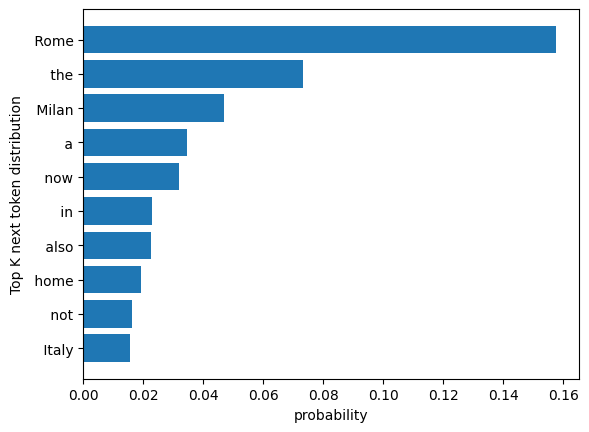



Prompt: The meaning of life is


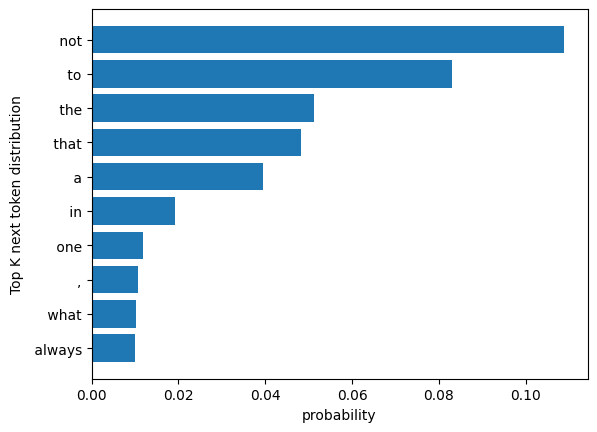



Prompt: Tomorrow I am going to


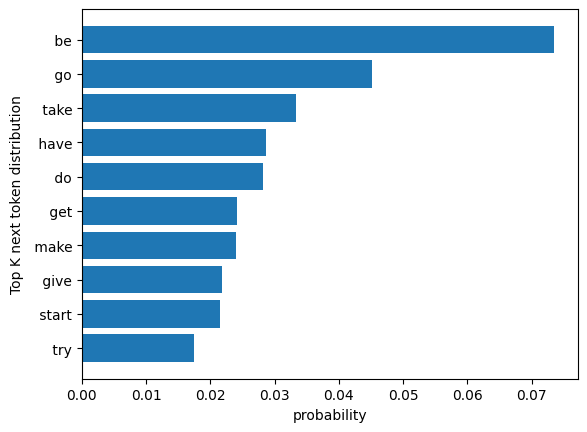

In [31]:
prompts = ["The capital of Italy is", "The meaning of life is", "Tomorrow I am going to"]

for p in prompts:
    print(f"\n\nPrompt: {p}")
    plot_top_k_distribution(p, k=10)

In [32]:
# Let's add temperatures

def plot_with_temperature(prompt, temperature=0.8, k=10):

    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k_: v.to(device) for k_, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
            
    logits = outputs.logits
    logits = logits[:, -1, :]
    logits = logits / temperature
    
    probs = F.softmax(logits, dim=-1)[0]

    top_probs, top_indices = torch.topk(probs, k)
    tokens = [tokenizer.decode([idx.item()]) for idx in top_indices]

    top_probs = top_probs.cpu().numpy()

    plt.figure()
    plt.barh(tokens[::-1], top_probs[::-1])
    plt.xlabel("probability")
    plt.ylabel("Top K next token distribution")
    plt.title(f"Temperature = {temperature}")

    plt.show()

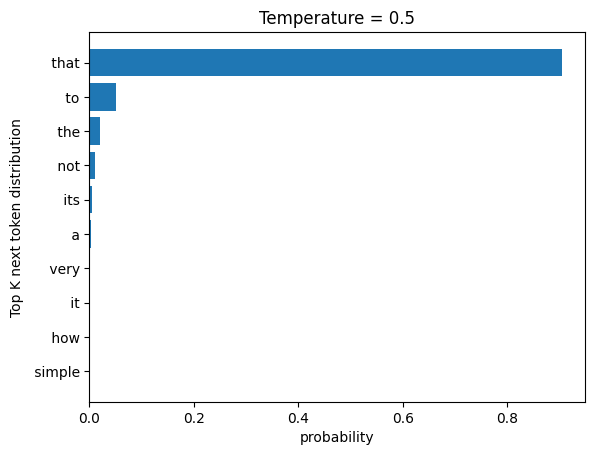

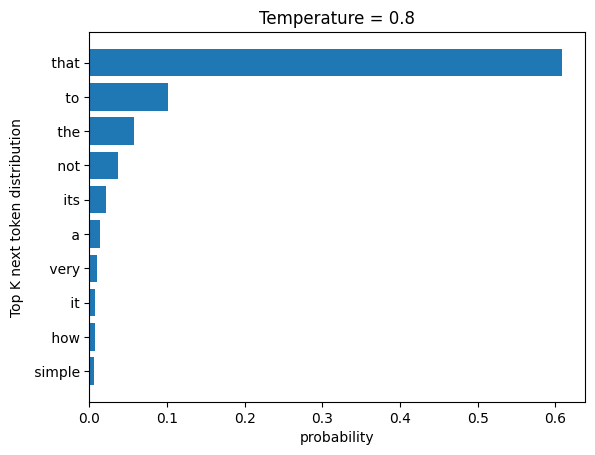

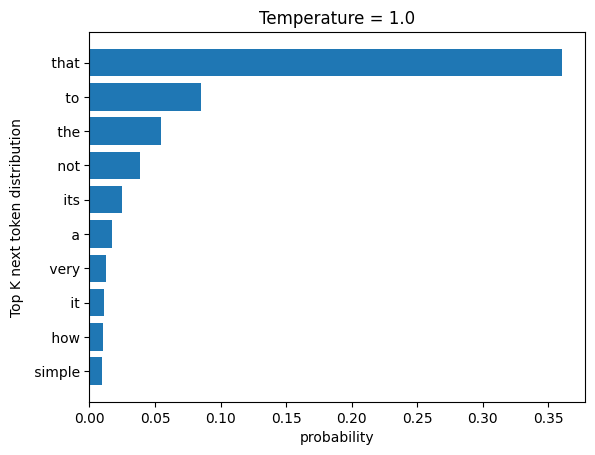

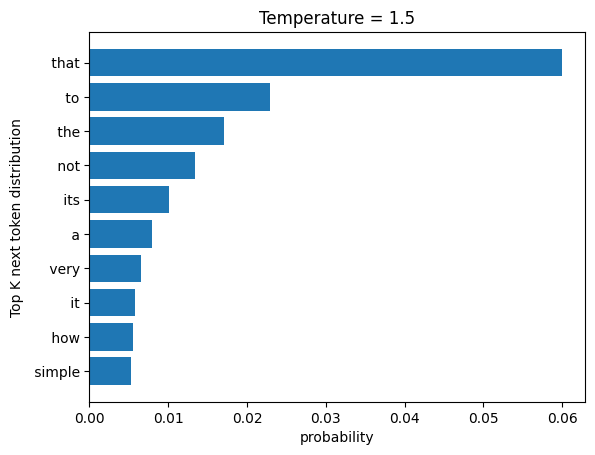

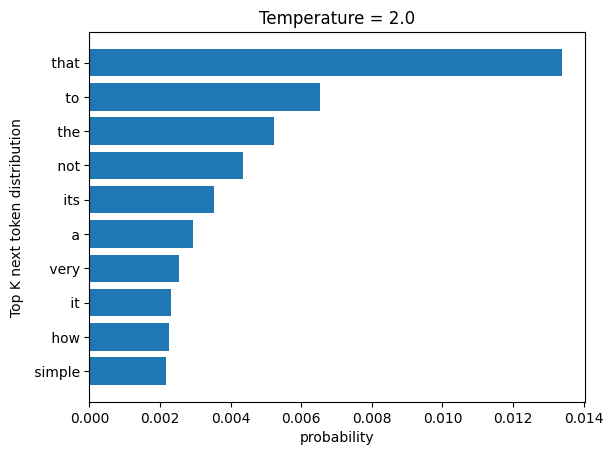

In [33]:
for T in [0.5, 0.8, 1.0, 1.5, 2.0]:
    plot_with_temperature("The feature of AI is", temperature=T)

This shows that the temperature doesn't change the possibole tokens, but just the shape of the distribution.

## 11. Entropy analysis

Entropy can be used to determine the uncertainty of the model when it makes a prediction.
* High entropy -> Uncertainty
* Low entropy -> Certainty

In [34]:
# Function to compute the entropy

def compute_entropy(probs):

    epsilon = 1e-10
    entropy = -torch.sum(probs * torch.log(probs + epsilon)) # Shannon entropy
    return entropy.item()

In [35]:
# Funtion to generate using the entropy

def generate_with_entropy(prompt, max_new_tokens=20, temperature=1.0):

    # Tokenize the input
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    input_ids = input_ids.to(device)

    entropies = []
    generated_tokens = []

    # Generate new tokens
    for step in range(max_new_tokens):
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            
        logits = outputs.logits[:, -1, :]
        logits = logits / temperature

        probs = F.softmax(logits, dim=-1)[0]

        entropy = compute_entropy(probs)
        entropies.append(entropy)

        next_token_id = torch.multinomial(probs, num_samples=1).unsqueeze(0)

        token_str = tokenizer.decode([next_token_id.item()])
        generated_tokens.append(token_str)
        input_ids = torch.cat([input_ids, next_token_id], dim=-1)

    generated_text = tokenizer.decode(input_ids[0])

    return generated_text, entropies, generated_tokens

In [36]:
# Plot entropies

def plot_entropy(entropies, tokens):

    plt.figure(figsize=(15,8))
    plt.plot(entropies, marker='o')

    plt.xticks(range(len(tokens)), tokens, rotation=45)
    
    plt.xlabel("Generated tokens")
    plt.ylabel("Entropy")

    plt.tight_layout()
    plt.show()

The future of AI is still very much a mystery. We're still waiting for a lot more research, but there's definitely


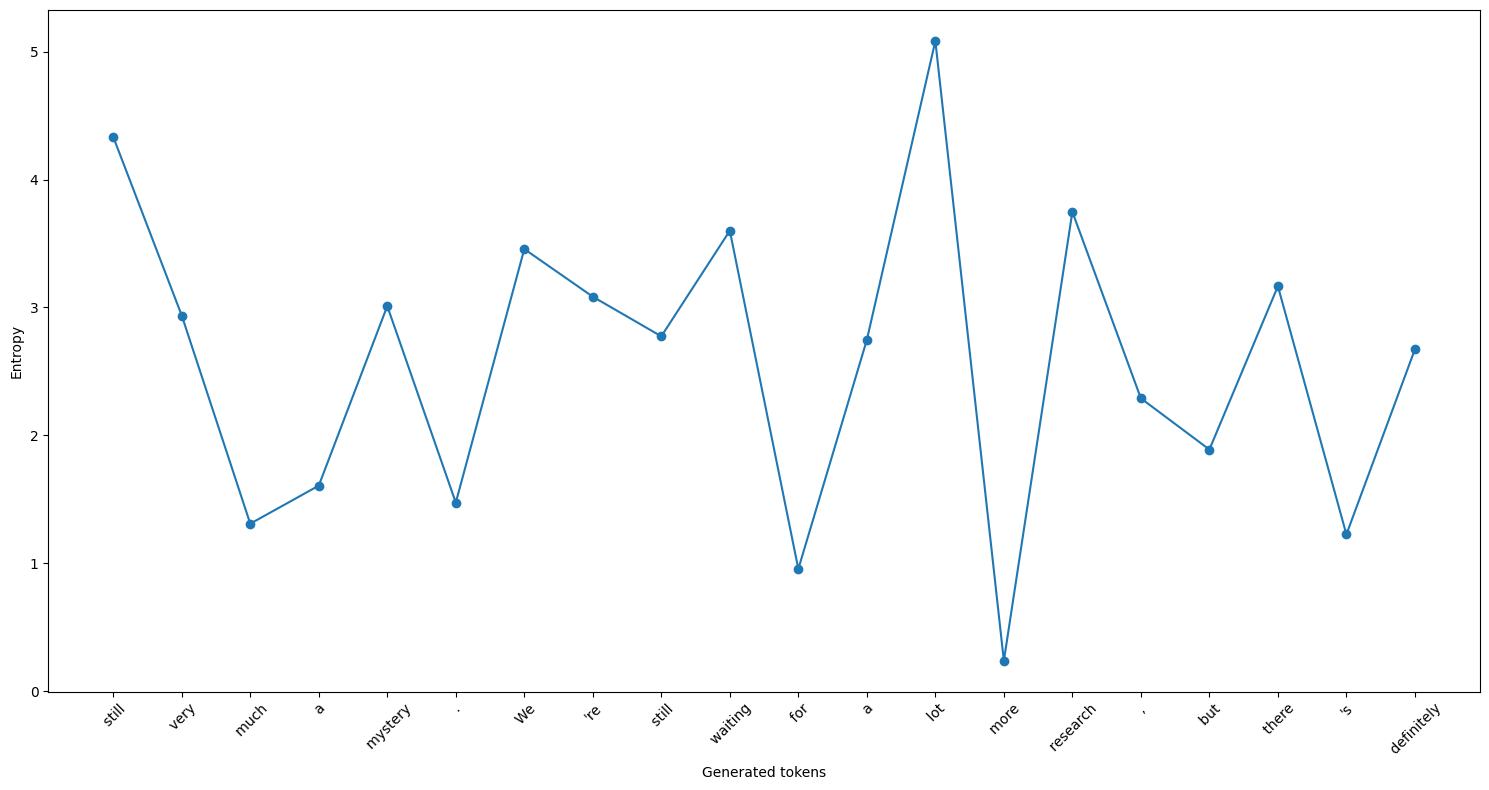

In [38]:
# Test

text, entropies, tokens = generate_with_entropy("The future of AI is", max_new_tokens=20, temperature=0.8)

print(text)
plot_entropy(entropies, tokens)

## 12. Prompt sensitivity analysis

I investigate how small changes in the input can affect the output.

In [40]:
# Small variations of the prompt

prompts = ["The capital of France is", "France's capital is", "The capital city of France is", "In France, the capital is"]

for p in prompts:
    print("\nPrompt: ", p)
    print(generate(p, max_new_tokens=15, strategy="top_p", temperature=0.8, top_p=0.9))


Prompt:  The capital of France is
The capital of France is under attack from a gang of women who threaten to kill them and kill journalists

Prompt:  France's capital is
France's capital is the site of a new government-owned property development in the heart of the

Prompt:  The capital city of France is
The capital city of France is now home to one of the world's largest hospitals and one of the world

Prompt:  In France, the capital is
In France, the capital is not known for the freedom of speech, but it has been toying with


Rather than giving the answer, it seems to provide information, for all the cases.

In [41]:
# Ambiguous prompts

prompts = ["He went to the bank to", "He went to the bank to withdraw money", "He went to the river bank to"]

for p in prompts:
    print("\nPrompt: ", p)
    print(generate(p, max_new_tokens=15, strategy="top_p", temperature=0.8, top_p=0.9))


Prompt:  He went to the bank to
He went to the bank to get some money, but there was a huge line of kids in the middle

Prompt:  He went to the bank to withdraw money
He went to the bank to withdraw money, and the bank made a note of it and sent it to the bank

Prompt:  He went to the river bank to
He went to the river bank to help her, but he couldn't help himself, he said.




In [42]:
# Guided prompt

prompts = ["Explain AI", "Explain AI in simple terms", "Explain AI in one sentence", "Explain AI like I'm 5 years old"]

for p in prompts:
    print("\nPrompt: ", p)
    print(generate(p, max_new_tokens=15, strategy="top_p", temperature=0.8, top_p=0.9))


Prompt:  Explain AI
Explain AI techniques to the world and bring about a world that is more peaceful and more

Prompt:  Explain AI in simple terms
Explain AI in simple terms and other tools that can be used to teach you to use AI.


Prompt:  Explain AI in one sentence
Explain AI in one sentence!

A sentence is a set of sentences, written in a way

Prompt:  Explain AI like I'm 5 years old
Explain AI like I'm 5 years old and I have 5 people who understand and love to interact with me.

